In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'font.size': 12,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11
})
from biot_gassmann import gassmann,biot_gassmann_wood,biot_gassmann_hill,biot_global_flow
from utils import modulus_to_velocity

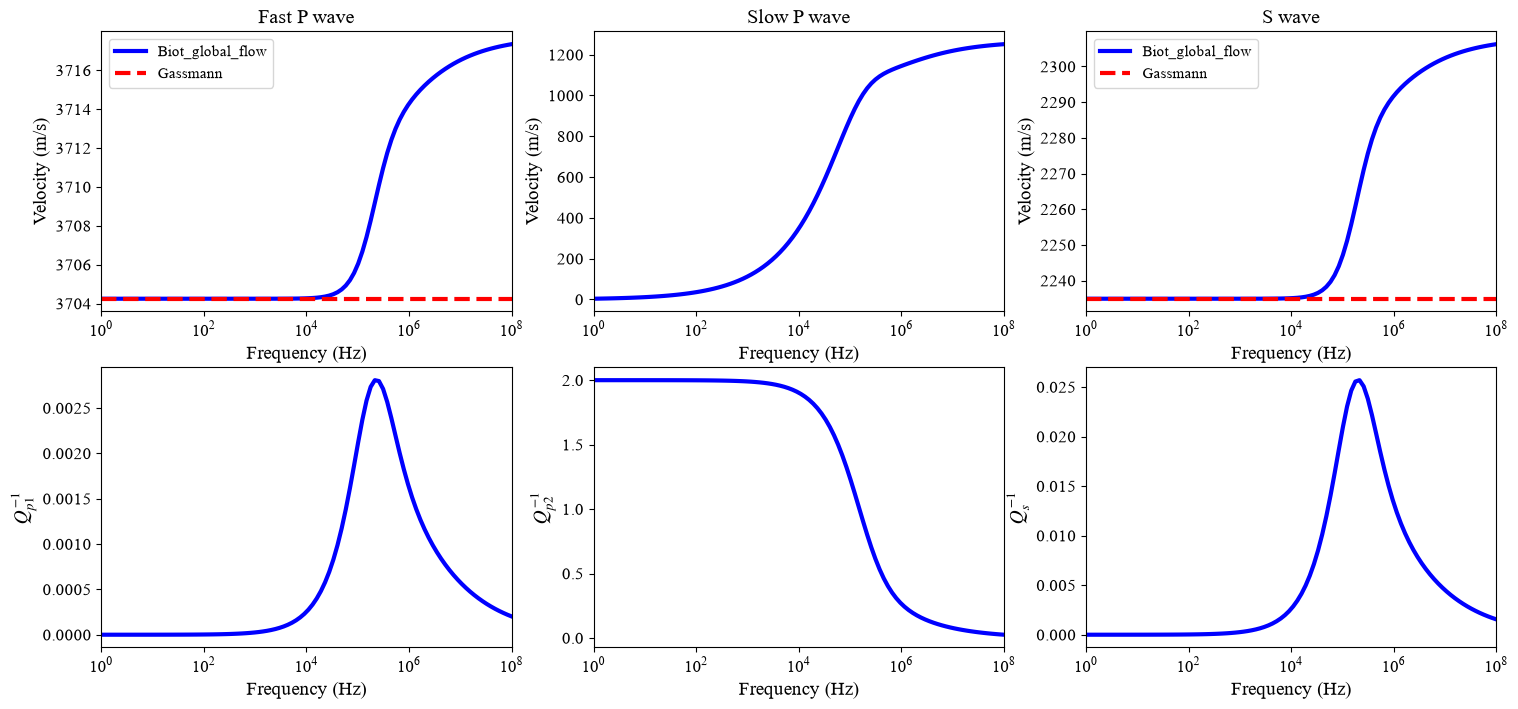

In [5]:
Ks   = 38e9 # Pa
Gs   = 44e9
rhos = 2.65e3 # Kg/m^3
Kd   = 10e9
Gd   = 12e9
phi  = 0.15
Kf   = 2.4e9
rhof = 1e3
vis  = 1e-3 # Pa·s
perm0= 100e-15# 100 mD
tau  = 1
f    = np.logspace(0,8,100)
Vp1,Vp2,Vs,inv_Qp1,inv_Qp2,inv_Qs = biot_global_flow(Ks,Gs,rhos,Kd,Gd,phi,Kf,rhof,vis,perm0,tau,f)

Ksat,Gsat = gassmann(Kd,Gd,Ks,Kf,phi)
rho = rhof*phi + (1-phi)*rhos
Vp_sat,Vs_sat = modulus_to_velocity(Ksat,Gsat,rho)
Vp_low = np.linspace(Vp_sat,Vp_sat,len(f))
Vs_low = np.linspace(Vs_sat,Vs_sat,len(f))

plt.figure(figsize=(18,8))
plt.subplot(2,3,1)
plt.semilogx(f,Vp1,
             label='Biot_global_flow',color='blue',linewidth=3)
plt.semilogx(f,Vp_low,
             label='Gassmann',color='red',linestyle='--',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Velocity (m/s)')
plt.title('Fast P wave')
plt.legend()
plt.xlim(1e0,1e8)

plt.subplot(2,3,2)
plt.semilogx(f,Vp2,color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Velocity (m/s)')
plt.title('Slow P wave')
plt.xlim(1e0,1e8)

plt.subplot(2,3,3)
plt.semilogx(f,Vs,label='Biot_global_flow',color='blue',linewidth=3)
plt.semilogx(f,Vs_low,label='Gassmann',color='red',linestyle='--',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Velocity (m/s)')
plt.title('S wave')
plt.legend()
plt.xlim(1e0,1e8)

plt.subplot(2,3,4)
plt.semilogx(f,inv_Qp1,color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$Q_{p1}^{-1}$')
plt.xlim(1e0,1e8)

plt.subplot(2,3,5)
plt.semilogx(f,inv_Qp2,color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$Q_{p2}^{-1}$')
plt.xlim(1e0,1e8)

plt.subplot(2,3,6)
plt.semilogx(f,inv_Qs,color='blue',linewidth=3)
plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$Q_{s}^{-1}$')
plt.xlim(1e0,1e8)

plt.show()